In [141]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import math

# ── Parameters ──────────────────────────────────────────
STEP = 0          # which denoising step
# BLOCK = 0         # 0~4 = double-stream, 5~24 = single-stream
HEATMAP_DIR = "./maps_a_cat_on_a_table__block_16"
HEATMAP_DIR = "./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world"
HEATMAP_DIR = "./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world__block_16"
HEATMAP_DIR = "./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world__block_2"
HEATMAP_DIR = "./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world__block_8"
HEATMAP_DIR = "./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world__block_32"
HEATMAP_DIR = "./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world__block_LinearBlockRadius(start=32, end=4)"


maps = torch.load(f"{HEATMAP_DIR}/step_{STEP:03d}.pt")
# shape: (25, Seq_img, Seq_img)  -- 5 double-stream + 20 single-stream blocks
print(f"maps.shape = {maps.shape}")

Seq_img = maps.shape[1]
H_GRID = W_GRID = int(math.isqrt(Seq_img))
print(f"H_GRID = W_GRID = {H_GRID}  (Seq_img={Seq_img})")


maps.shape = torch.Size([25, 4096, 4096])
H_GRID = W_GRID = 64  (Seq_img=4096)


In [142]:
maps[0][0]

tensor([0.0671, 0.0453, 0.0228,  ..., 0.0000, 0.0000, 0.0000],
       dtype=torch.float16)

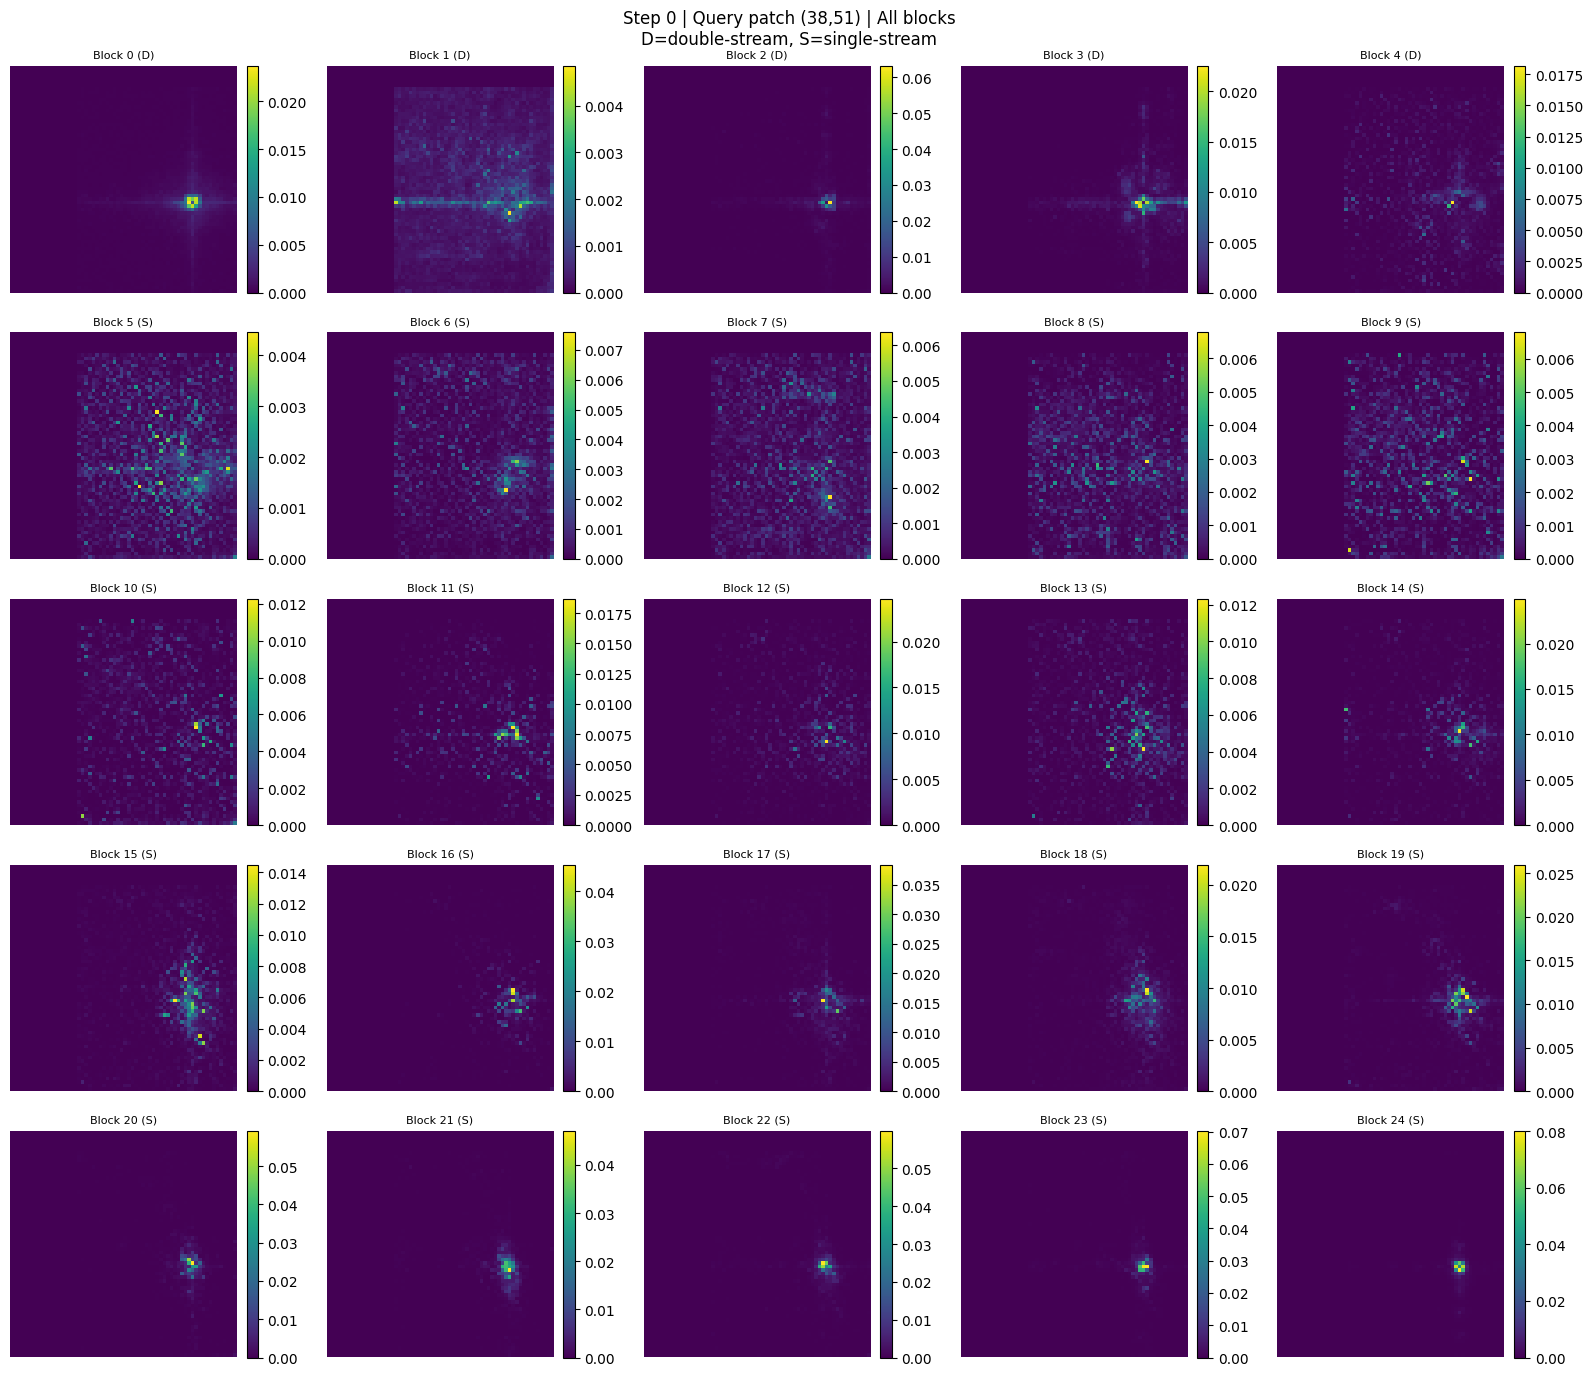

In [143]:
def plot_all_blocks(maps, step, query_row, query_col, cmap="viridis", figsize=(16, 14), color_bar=True):
    """5×5 grid showing attention heatmap for all 25 blocks at a given query patch."""
    query_idx = query_row * W_GRID + query_col
    fig, axes = plt.subplots(5, 5, figsize=figsize)
    for b, ax in enumerate(axes.flat):
        m = maps[b][query_idx].reshape(H_GRID, W_GRID).numpy()
        im = ax.imshow(m, cmap=cmap)
        if color_bar:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        stream = "D" if b < 5 else "S"
        ax.set_title(f"Block {b} ({stream})", fontsize=8)
        ax.axis("off")
    plt.suptitle(
        f"Step {step} | Query patch ({query_row},{query_col}) | All blocks\n"
        "D=double-stream, S=single-stream"
    )
    plt.tight_layout()
    return fig

# Preview
query_row, query_col = int(H_GRID * 0.6), int(W_GRID * 0.8)
fig = plot_all_blocks(maps, STEP, query_row, query_col)
plt.show()

In [144]:
import io
import glob as _glob
from pathlib import Path
from PIL import Image

GIF_PATH = f"{HEATMAP_DIR}/attn_steps.gif"
GIF_DPI = 72          # lower = smaller file
GIF_DURATION = 600    # ms per frame

step_files = sorted(Path(HEATMAP_DIR).glob("step_*.pt"))
print(f"Found {len(step_files)} step files")

frames = []
for path in step_files:
    step_num = int(path.stem.split("_")[1])
    m = torch.load(path)
    fig = plot_all_blocks(m, step_num, query_row, query_col, figsize=(10, 9), color_bar=False)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=GIF_DPI)
    plt.close(fig)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    print(f"  rendered step {step_num}")

frames[0].save(
    GIF_PATH,
    save_all=True,
    append_images=frames[1:],
    duration=GIF_DURATION,
    loop=0,
)
print(f"Saved GIF → {GIF_PATH}")

Found 4 step files
  rendered step 0
  rendered step 1
  rendered step 2
  rendered step 3
Saved GIF → ./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world__block_LinearBlockRadius(start=32, end=4)/attn_steps.gif


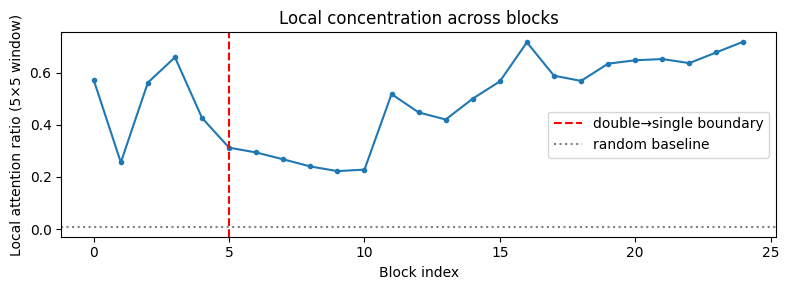

In [145]:
def local_concentration(attn_2d, H, W, window=5):
    """
    Fraction of each query token's attention that falls within a window×window neighborhood.
    Returns the mean across all tokens.
    """
    half = window // 2
    scores = []
    for r in range(H):
        for c in range(W):
            q_idx = r * W + c
            row_attn = attn_2d[q_idx]  # softmax-normalized, sums to 1
            r_min, r_max = max(0, r - half), min(H, r + half + 1)
            c_min, c_max = max(0, c - half), min(W, c + half + 1)
            neighbor_idxs = [
                rr * W + cc
                for rr in range(r_min, r_max)
                for cc in range(c_min, c_max)
            ]
            scores.append(row_attn[neighbor_idxs].sum().item())
    return np.mean(scores)

def attention_entropy(attn_2d):
    """
    Shannon entropy per row; lower = more concentrated, higher = more diffuse.
    """
    p = attn_2d.float().clamp(min=1e-9)
    h = -(p * p.log()).sum(dim=-1)  # (N,)
    return h.mean().item()

concentration = []
entropy = []

for b in range(maps.shape[0]):
    concentration.append(local_concentration(maps[b], H_GRID, W_GRID, window=16))
    entropy.append(attention_entropy(maps[b]))

# ── Plot 1: local concentration ──────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(concentration, marker="o", ms=3)
plt.axvline(5, color="r", linestyle="--", label="double→single boundary")
plt.axhline(25 / Seq_img, color="gray", linestyle=":", label="random baseline")
plt.xlabel("Block index")
plt.ylabel("Local attention ratio (5×5 window)")
plt.title("Local concentration across blocks")
plt.legend()
plt.tight_layout()
plt.show()


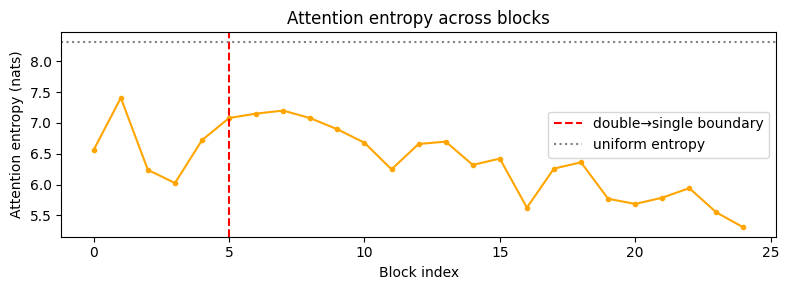

In [146]:

# ── Plot 2: attention entropy ─────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(entropy, marker="o", ms=3, color="orange")
plt.axvline(5, color="r", linestyle="--", label="double→single boundary")
plt.axhline(math.log(Seq_img), color="gray", linestyle=":", label="uniform entropy")
plt.xlabel("Block index")
plt.ylabel("Attention entropy (nats)")
plt.title("Attention entropy across blocks")
plt.legend()
plt.tight_layout()
plt.show()

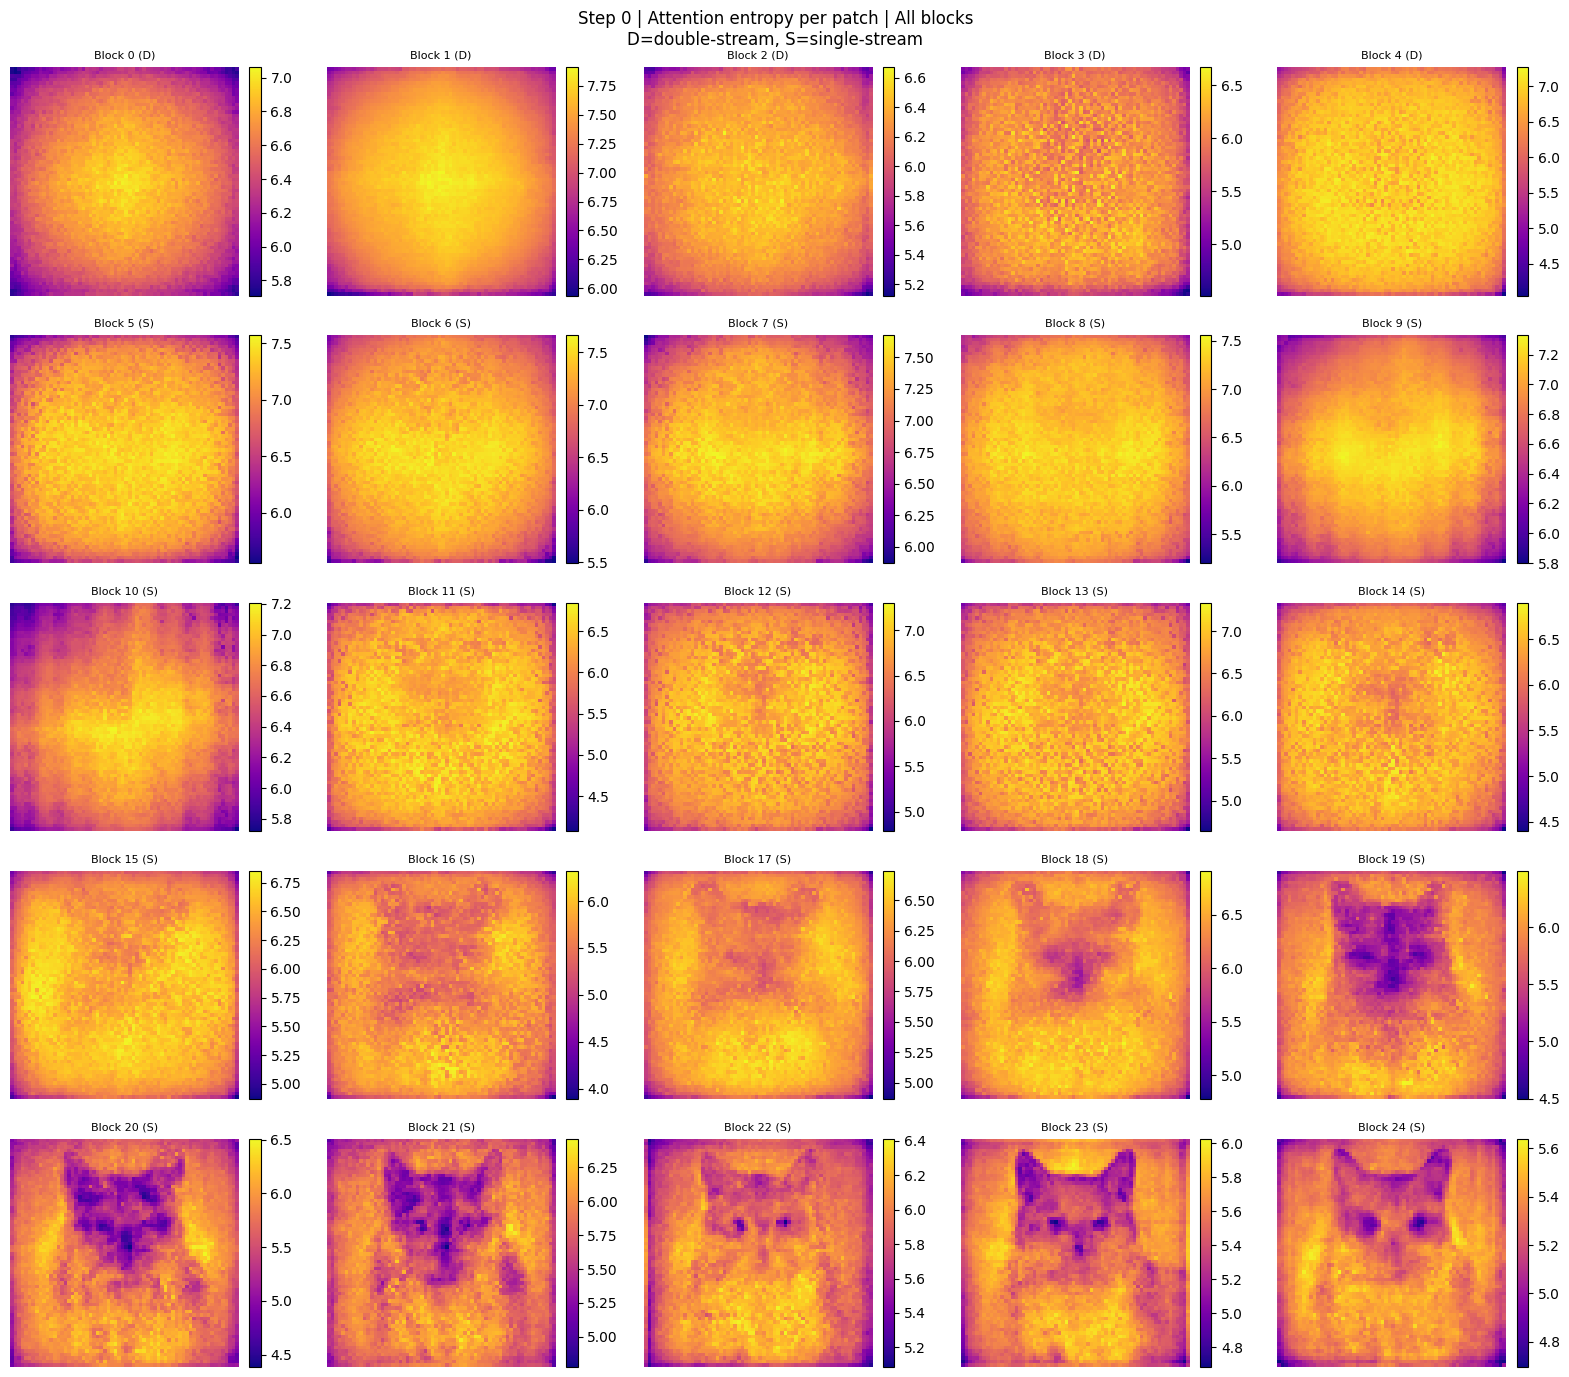

In [147]:
def plot_entropy_all_blocks(maps, step, figsize=(16, 14), color_bar=True):
    """5×5 grid showing per-patch attention entropy for all 25 blocks."""
    fig, axes = plt.subplots(5, 5, figsize=figsize)
    for b, ax in enumerate(axes.flat):
        attn = maps[b].float()
        eps = 1e-8
        entropy = -(attn * (attn + eps).log()).sum(dim=-1)
        entropy_map = entropy.reshape(H_GRID, W_GRID).numpy()
        im = ax.imshow(entropy_map, cmap="plasma")
        if color_bar:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        stream = "D" if b < 5 else "S"
        ax.set_title(f"Block {b} ({stream})", fontsize=8)
        ax.axis("off")
    plt.suptitle(
        f"Step {step} | Attention entropy per patch | All blocks\n"
        "D=double-stream, S=single-stream"
    )
    plt.tight_layout()
    return fig

# Preview
fig = plot_entropy_all_blocks(maps, STEP)
plt.show()

In [148]:
ENTROPY_ALL_GIF_PATH = f"{HEATMAP_DIR}/entropy_all_blocks_steps.gif"
ENTROPY_ALL_GIF_DPI = 72
ENTROPY_ALL_GIF_DURATION = 600  # ms per frame

step_files = sorted(Path(HEATMAP_DIR).glob("step_*.pt"))
print(f"Found {len(step_files)} step files")

frames = []
for path in step_files:
    step_num = int(path.stem.split("_")[1])
    m = torch.load(path)
    fig = plot_entropy_all_blocks(m, step_num, figsize=(10, 9), color_bar=False)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=ENTROPY_ALL_GIF_DPI)
    plt.close(fig)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    print(f"  rendered step {step_num}")

frames[0].save(
    ENTROPY_ALL_GIF_PATH,
    save_all=True,
    append_images=frames[1:],
    duration=ENTROPY_ALL_GIF_DURATION,
    loop=0,
)
print(f"Saved GIF → {ENTROPY_ALL_GIF_PATH}")

Found 4 step files
  rendered step 0
  rendered step 1
  rendered step 2
  rendered step 3
Saved GIF → ./maps_better_resolution,_photo-realistic,_a_cat_saying_hello_world__block_LinearBlockRadius(start=32, end=4)/entropy_all_blocks_steps.gif
